# EMA6938 — Data Science for Materials
## Week 5 Lab Notebook: ML Foundations, Tree-Based Models & Materials Descriptors

**Name:** *ANOSIKE KELECHI KENNETH*  
**Date:** *6/10/2026*  
**Kernel:** Python (matds)

**CLAUDE-AI ASSISTED SOLUTIONS**

---

**Chapters:** Sandfeld Ch. 11 + Lecture  
**Format:** Take-home. Due **Sunday 11:59 PM**.

**Dataset:** `data/week5_mp_featurized.csv` (instructor-provided, save in the same folder as this notebook)

---

### How to use this notebook
- **Demo cells** (`# LECTURE DEMO`) reproduce examples from the lecture. Run them, understand them.
- **Task cells** (`# YOUR CODE HERE`) require you to write code.
- **Reflection cells** require written markdown answers. Replace the italic placeholder text.
- Complete Parts A–C first (load, split, train). Parts D–F build on them.

---

**Submission:** Upload this `.ipynb` file to Canvas. Run `Kernel → Restart & Run All` before submitting to confirm all cells execute cleanly.

> **AI tool disclosure:** If you used any AI coding assistant (GitHub Copilot, ChatGPT, etc.) while completing this notebook, describe briefly which tool, for what purpose, and what you verified yourself. Delete this line if no AI tools were used.
---

**Final project reminder:** Topic proposal (1 paragraph) due this week! Submit via Canvas.

In [1]:
# Cell 0 — Environment check
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, learning_curve
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

print(f'Python:      {sys.version.split()[0]}')
print(f'NumPy:       {np.__version__}')
print(f'pandas:      {pd.__version__}')
print(f'scikit-learn: already imported above')
print('\n\u2713 All imports successful.')

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.4,
    'grid.linestyle': '--',
})

Python:      3.10.20
NumPy:       1.26.4
pandas:      2.3.3
scikit-learn: already imported above

✓ All imports successful.


---
## Part A - Load & Prepare
**Connects to: Lecture Segment 2, Ch. 11**

### A1 - Load the featurized dataset
**Lecture demo - run and understand**

In [2]:
# Cell A1 - Load the featurized dataset
# LECTURE DEMO

df = pd.read_csv('data/week5_mp_featurized.csv')

print(f'Shape: {df.shape[0]:,} rows \u00d7 {df.shape[1]} columns')
print(f'\nFirst 5 columns: {list(df.columns[:5])}')
print(f'Last 5 columns:  {list(df.columns[-5:])}')
print(f'\nTarget column (band_gap):')
print(df['band_gap'].describe().round(3))

# Confirm MAGPIE features are present
magpie_cols = [c for c in df.columns if 'MagpieData' in c]
print(f'\nMAGPIE feature columns found: {len(magpie_cols)}')
print(f'Example: {magpie_cols[:3]}')

Shape: 9,389 rows × 137 columns

First 5 columns: ['mp_id', 'formula', 'band_gap', 'Ef_eV_atom', 'composition']
Last 5 columns:  ['MagpieData maximum SpaceGroupNumber', 'MagpieData range SpaceGroupNumber', 'MagpieData mean SpaceGroupNumber', 'MagpieData avg_dev SpaceGroupNumber', 'MagpieData mode SpaceGroupNumber']

Target column (band_gap):
count    9389.000
mean        1.772
std         1.657
min         0.000
25%         0.000
50%         1.565
75%         3.052
max         8.375
Name: band_gap, dtype: float64

MAGPIE feature columns found: 132
Example: ['MagpieData minimum Number', 'MagpieData maximum Number', 'MagpieData range Number']


### A2 - Drop missing values and report

In [3]:
# Cell A2 — Drop rows with missing band_gap or missing MAGPIE features
# LECTURE DEMO

n_before = len(df)

# Drop rows missing the target
df = df.dropna(subset=['band_gap'])

# Drop rows missing any MAGPIE feature
df = df.dropna(subset=magpie_cols)

n_after = len(df)
print(f'Rows before: {n_before:,}')
print(f'Rows after:  {n_after:,}')
print(f'Dropped:     {n_before - n_after:,} ({100*(n_before-n_after)/n_before:.1f}%)')
print(f'\nband_gap range: {df["band_gap"].min():.2f} \u2013 {df["band_gap"].max():.2f} eV')

Rows before: 9,389
Rows after:  9,389
Dropped:     0 (0.0%)

band_gap range: 0.00 – 8.38 eV


### A3 - Separate X and y
**Lecture demo**

In [4]:
# Cell A3 — Separate feature matrix X and target vector y
# LECTURE DEMO

X = df[magpie_cols].copy()
y = df['band_gap'].copy()

print(f'X shape: {X.shape}  (samples \u00d7 features)')
print(f'y shape: {y.shape}')
print(f'\ny (band_gap) summary:')
print(y.describe().round(3))

X shape: (9389, 132)  (samples × features)
y shape: (9389,)

y (band_gap) summary:
count    9389.000
mean        1.772
std         1.657
min         0.000
25%         0.000
50%         1.565
75%         3.052
max         8.375
Name: band_gap, dtype: float64


---
## Part B - Train/Test Split
**Connects to: Lecture Segment 3, Ch. 11**

### B1 - Stratified 80/20 split
**Lecture demo**

In [5]:
# Cell B1 — Stratified train/test split
# LECTURE DEMO

# Bin the target for stratification
# Cell B1 — Stratified train/test split
# LECTURE DEMO

# Bin the target for stratification
y_binned = pd.qcut(y, q=5, labels=False, duplicates='drop')

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y_binned
)

print(f'Train: {len(X_train):,} samples')
print(f'Test:  {len(X_test):,} samples')
print(f'Train y mean: {y_train.mean():.3f} eV  Test y mean: {y_test.mean():.3f} eV')
print(f'Train y std:  {y_train.std():.3f} eV  Test y std:  {y_test.std():.3f} eV')

Train: 7,511 samples
Test:  1,878 samples
Train y mean: 1.770 eV  Test y mean: 1.778 eV
Train y std:  1.658 eV  Test y std:  1.655 eV


### B2 - Confirm distributions match

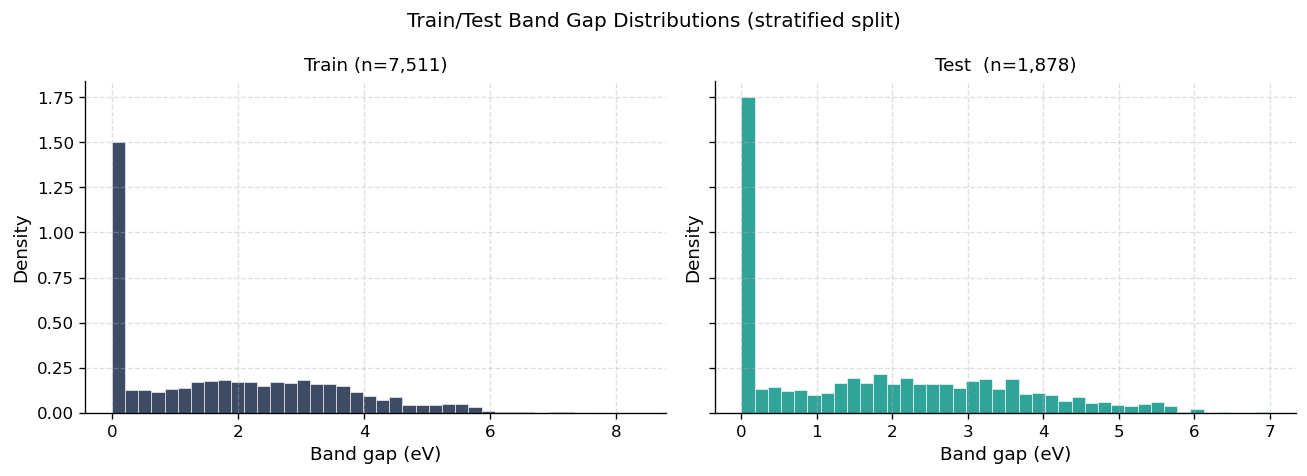

In [6]:
# Cell B2 — Plot y_train and y_test distributions side by side
# LECTURE DEMO

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)

for ax, data, label, color in [
    (axes[0], y_train, f'Train (n={len(y_train):,})', '#1C2B4A'),
    (axes[1], y_test,  f'Test  (n={len(y_test):,})',  '#0D9488'),
]:
    ax.hist(data, bins=40, color=color, alpha=0.85,
            density=True, edgecolor='white', linewidth=0.4)
    ax.set_xlabel('Band gap (eV)', fontsize=11)
    ax.set_ylabel('Density', fontsize=11)
    ax.set_title(label, fontsize=11)

plt.suptitle('Train/Test Band Gap Distributions (stratified split)', fontsize=12)
plt.tight_layout()
plt.savefig('B2_train_test_distributions.png', dpi=150)
plt.show()

---
## Part C - Train and Compare Three Models
**Connects to: Lecture Segment 4, Ch. 11**

### C1 — Decision tree baseline

In [7]:
# Cell C1 — Decision tree (max_depth=5)
# LECTURE DEMO

dt = DecisionTreeRegressor(max_depth=5, random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

mae_dt  = mean_absolute_error(y_test, y_pred_dt)
rmse_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt))
r2_dt   = r2_score(y_test, y_pred_dt)

print('Decision Tree (max_depth=5):')
print(f'  MAE:  {mae_dt:.3f} eV')
print(f'  RMSE: {rmse_dt:.3f} eV')
print(f'  R\u00b2:   {r2_dt:.3f}')

Decision Tree (max_depth=5):
  MAE:  0.946 eV
  RMSE: 1.192 eV
  R²:   0.481


### C2 - Random forest
**Lecture demo**

In [8]:
# Cell C2 — Random forest (n_estimators=100)
# LECTURE DEMO

rf = RandomForestRegressor(
    n_estimators=100,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

mae_rf  = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf   = r2_score(y_test, y_pred_rf)

print('Random Forest (n_estimators=100):')
print(f'  MAE:  {mae_rf:.3f} eV')
print(f'  RMSE: {rmse_rf:.3f} eV')
print(f'  R\u00b2:   {r2_rf:.3f}')

Random Forest (n_estimators=100):
  MAE:  0.563 eV
  RMSE: 0.779 eV
  R²:   0.778


### C3 - Gradient boosting

In [9]:
# Cell C3 - Gradient boosting
# LECTURE DEMO

gb = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)

mae_gb  = mean_absolute_error(y_test, y_pred_gb)
rmse_gb = np.sqrt(mean_squared_error(y_test, y_pred_gb))
r2_gb   = r2_score(y_test, y_pred_gb)

print('Gradient Boosting (n_estimators=200, lr=0.05):')
print(f'  MAE:  {mae_gb:.3f} eV')
print(f'  RMSE: {rmse_gb:.3f} eV')
print(f'  R\u00b2:   {r2_gb:.3f}')

Gradient Boosting (n_estimators=200, lr=0.05):
  MAE:  0.706 eV
  RMSE: 0.888 eV
  R²:   0.712


### C4 - Comparison table and prediction scatter
**Task**

Model                  MAE (eV)  RMSE (eV)       R²
----------------------------------------------------
Decision Tree             0.946      1.192    0.481
Random Forest             0.563      0.779    0.778
Gradient Boosting         0.706      0.888    0.712

Best model: Random Forest


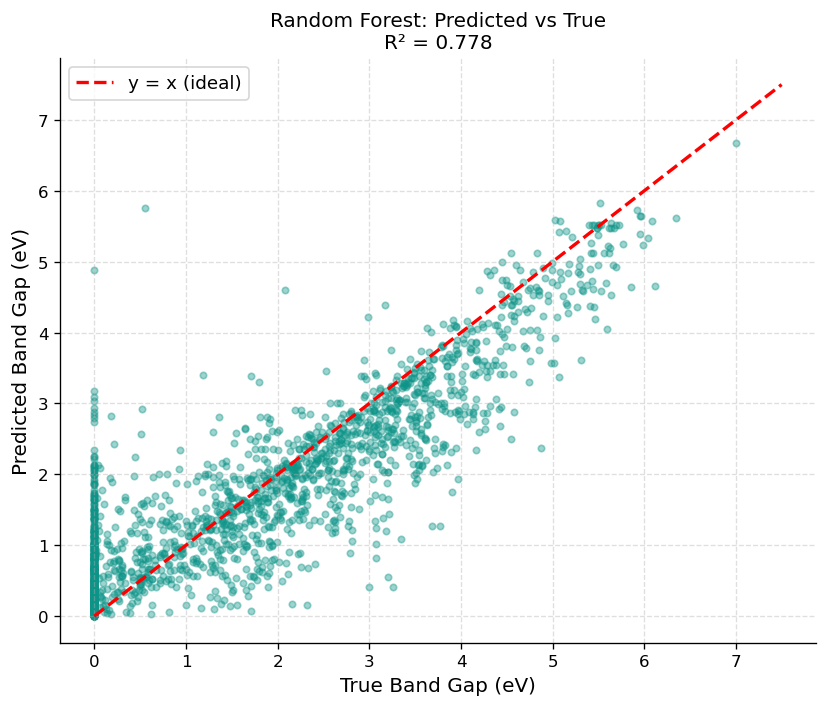

In [10]:
# Cell C4 — Model comparison table + prediction vs truth scatter
# YOUR CODE HERE

# 1. Print a formatted comparison table:
#    Model | MAE (eV) | RMSE (eV) | R²
#    Decision Tree | ... | ... | ...
#    Random Forest | ... | ... | ...
#    Gradient Boost| ... | ... | ...

# 2. For the best model, plot: y_test (x-axis) vs y_pred (y-axis)
#    Add a y=x diagonal line. Label axes. Add R² to the title.

# YOUR CODE HERE


# 1. Print formatted comparison table
models = {
    'Decision Tree':    (mae_dt,  rmse_dt,  r2_dt),
    'Random Forest':    (mae_rf,  rmse_rf,  r2_rf),
    'Gradient Boosting':(mae_gb,  rmse_gb,  r2_gb),
}

print(f"{'Model':<20} {'MAE (eV)':>10} {'RMSE (eV)':>10} {'R²':>8}")
print("-" * 52)
for name, (mae, rmse, r2) in models.items():
    print(f"{name:<20} {mae:>10.3f} {rmse:>10.3f} {r2:>8.3f}")

# 2. Find best model by R²
best_name = max(models, key=lambda k: models[k][2])
print(f"\nBest model: {best_name}")

# Get best model predictions
best_pred = {'Decision Tree': y_pred_dt,
             'Random Forest': y_pred_rf,
             'Gradient Boosting': y_pred_gb}[best_name]

# Scatter plot: y_test vs y_pred
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(y_test, best_pred, color='#0D9488', alpha=0.4, s=15)
lim = max(y_test.max(), best_pred.max()) + 0.5
ax.plot([0, lim], [0, lim], 'r--', lw=2, label='y = x (ideal)')
ax.set_xlabel('True Band Gap (eV)', fontsize=12)
ax.set_ylabel('Predicted Band Gap (eV)', fontsize=12)
ax.set_title(f'{best_name}: Predicted vs True\nR² = {models[best_name][2]:.3f}', fontsize=12)
ax.legend(fontsize=11)
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('C4_pred_vs_truth.png', dpi=150)
plt.show()

**C4 Reflection** *(answer in this cell)*

Which model performed best? By how much does it beat the decision tree? Does the prediction vs. truth scatter show any systematic pattern (e.g. over-prediction at high bandgap)?

*Your answer here:*
Random Forest performed best with R² = 0.778 and MAE = 0.563 eV, beating the Decision Tree (R² = 0.481, MAE = 0.946 eV) by 0.297 in R² and 0.383 eV in MAE, and also outperforming Gradient Boosting (R² = 0.712). The prediction vs truth scatter shows a systematic pattern of under-prediction at high band gaps above 5 eV, which is physically expected because wide-gap compounds like BeO and B2O3 are rare in the training data and the model defaults toward the more common 1 to 3 eV oxide range.

---
## Part D - Interpret the Best Model
**Connects to: Lecture Segment 5, Ch. 11**

### D1 - Feature importance bar chart
**Lecture demo**

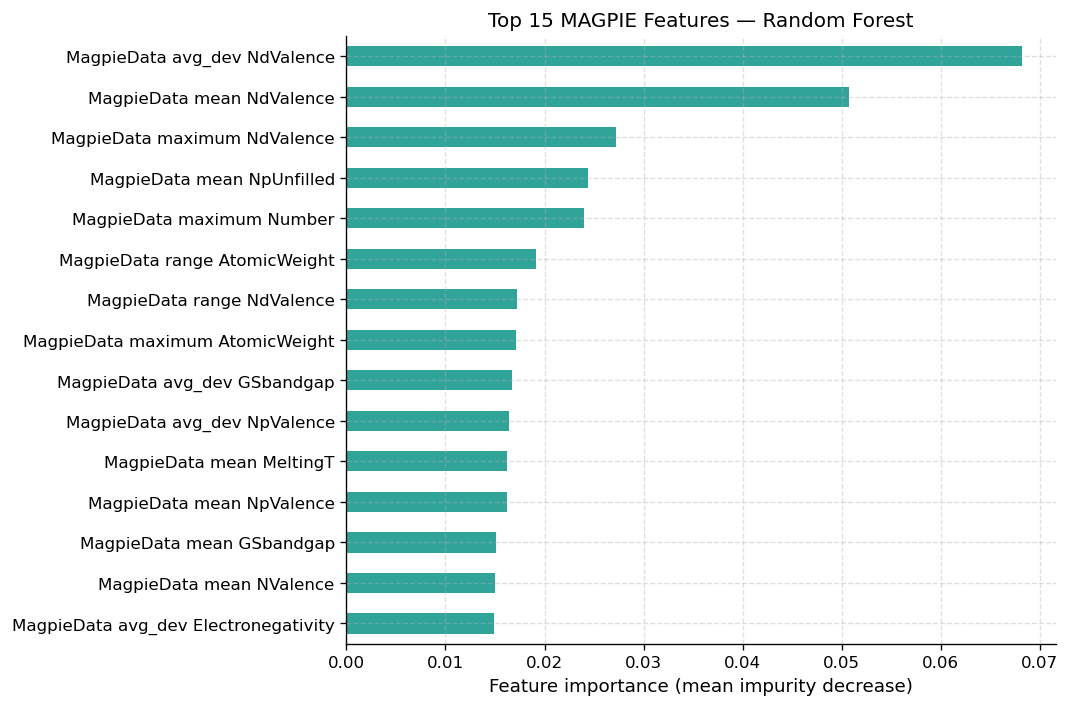

Top 10 features:
MagpieData avg_dev NdValence       0.0682
MagpieData mean NdValence          0.0508
MagpieData maximum NdValence       0.0272
MagpieData mean NpUnfilled         0.0244
MagpieData maximum Number          0.0240
MagpieData range AtomicWeight      0.0191
MagpieData range NdValence         0.0172
MagpieData maximum AtomicWeight    0.0171
MagpieData avg_dev GSbandgap       0.0168
MagpieData avg_dev NpValence       0.0165


In [11]:
# Cell D1 — Feature importance: top 15 MAGPIE features
# LECTURE DEMO  (uses rf - switch to gb if GB performed better)

best_model = rf   # change to gb if gradient boosting was better

importances = pd.Series(
    best_model.feature_importances_,
    index=magpie_cols
).sort_values(ascending=False)

top15 = importances.head(15)

fig, ax = plt.subplots(figsize=(9, 6))
top15.plot(kind='barh', ax=ax, color='#0D9488', alpha=0.85)
ax.invert_yaxis()
ax.set_xlabel('Feature importance (mean impurity decrease)', fontsize=11)
ax.set_title('Top 15 MAGPIE Features — Random Forest', fontsize=12)
plt.tight_layout()
plt.savefig('D1_feature_importance.png', dpi=150)
plt.show()

print('Top 10 features:')
print(top15.head(10).round(4).to_string())

### D2 - Residual plot

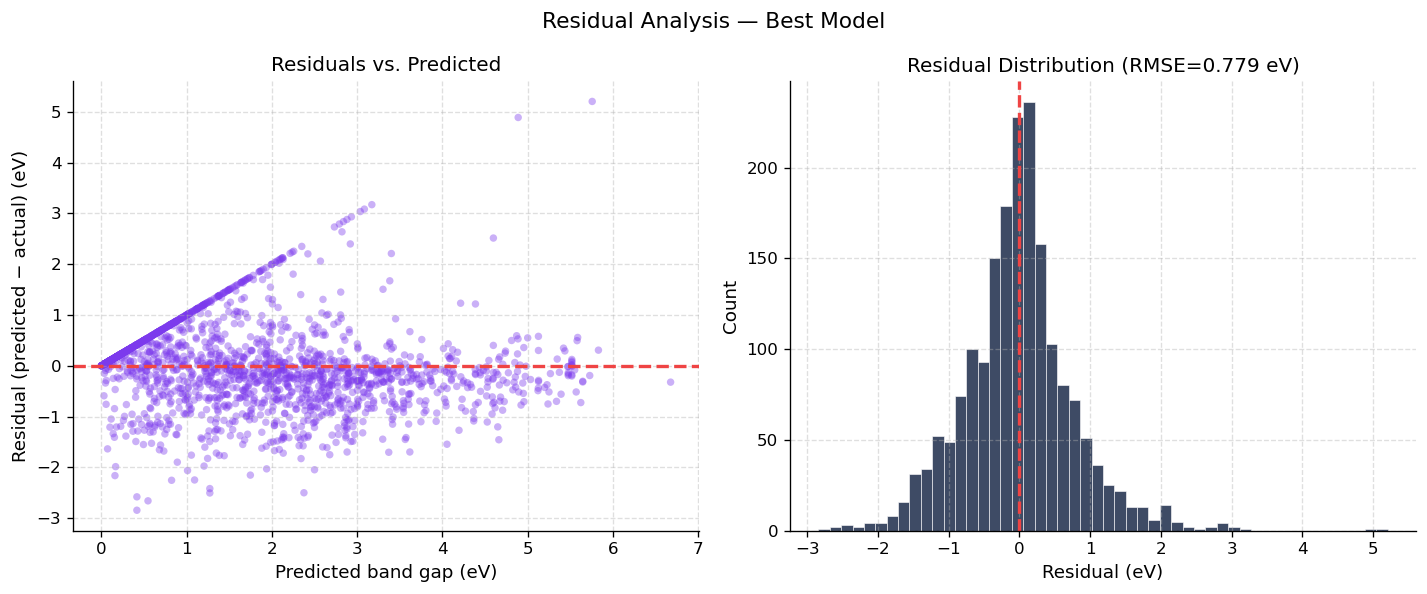

Mean residual: -0.0127 eV  (should be near 0)
Std residual:  0.7793 eV
Max |residual|: 5.204 eV

Largest error entry:
formula      Ca(BO2)3
band_gap       0.5526
mp_id       mp-729083
Name: 2034, dtype: object


In [12]:
# Cell D2 — Residual plot
# LECTURE DEMO

y_pred_best = best_model.predict(X_test)
residuals   = y_pred_best - y_test

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Residuals vs predicted
axes[0].scatter(y_pred_best, residuals, alpha=0.4, s=20, color='#7C3AED', edgecolors='none')
axes[0].axhline(0, color='#EF4444', ls='--', lw=2)
axes[0].set_xlabel('Predicted band gap (eV)', fontsize=11)
axes[0].set_ylabel('Residual (predicted \u2212 actual) (eV)', fontsize=11)
axes[0].set_title('Residuals vs. Predicted', fontsize=12)

# Residual histogram
axes[1].hist(residuals, bins=50, color='#1C2B4A', alpha=0.85,
             edgecolor='white', linewidth=0.4)
axes[1].axvline(0, color='#EF4444', ls='--', lw=2)
axes[1].set_xlabel('Residual (eV)', fontsize=11)
axes[1].set_ylabel('Count', fontsize=11)
axes[1].set_title(f'Residual Distribution (RMSE={rmse_rf:.3f} eV)', fontsize=12)

plt.suptitle('Residual Analysis — Best Model', fontsize=13)
plt.tight_layout()
plt.savefig('D2_residuals.png', dpi=150)
plt.show()

print(f'Mean residual: {residuals.mean():.4f} eV  (should be near 0)')
print(f'Std residual:  {residuals.std():.4f} eV')
print(f'Max |residual|: {residuals.abs().max():.3f} eV')
print(f'\nLargest error entry:')
worst_idx = residuals.abs().idxmax()
print(df.loc[worst_idx, ['formula','band_gap','mp_id']])

### D3 - Task: physical interpretation of top feature

Top feature: MagpieData avg_dev NdValence
Top feature: MagpieData avg_dev NdValence


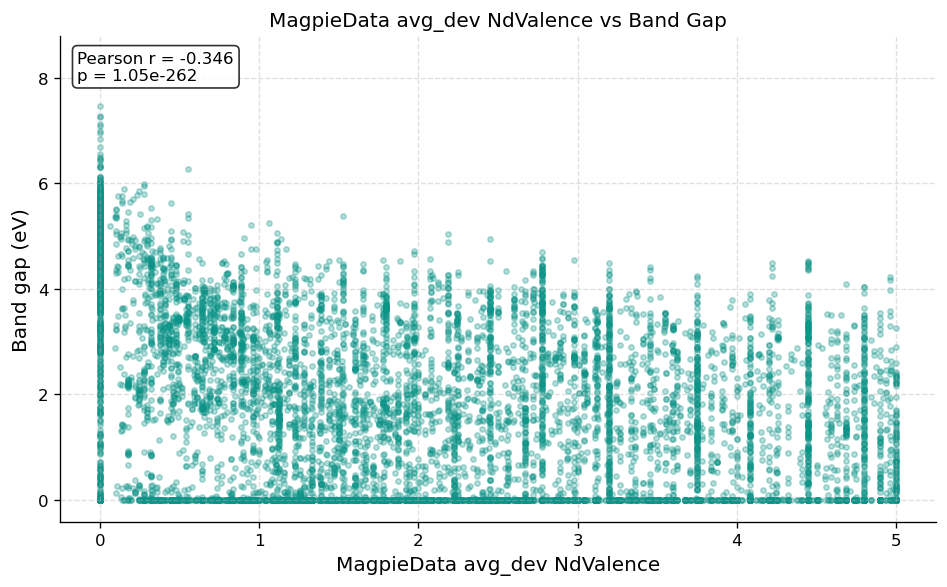

Pearson r = -0.3463, p = 1.05e-262


In [13]:
# Cell D3 — Task: scatter plot of top feature vs. band_gap
# YOUR CODE HERE

# 1. Identify the top-1 feature from D1
top_feature = importances.index[0]
print(f'Top feature: {top_feature}')

# 2. Make a scatter plot: top_feature (x) vs. band_gap (y)
#    Use df (not X_train/X_test) for this exploratory plot

# 3. Compute Pearson r between top_feature and band_gap

from scipy.stats import pearsonr

# 1. Identify top-1 feature from D1
top_feature = importances.index[0]
print(f'Top feature: {top_feature}')

# 2. Scatter plot using X (feature matrix) and y (target)
feature_idx = list(X.columns).index(top_feature)
feature_vals = X[top_feature]

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(feature_vals, y, color='#0D9488', alpha=0.3, s=10)
ax.set_xlabel(top_feature, fontsize=12)
ax.set_ylabel('Band gap (eV)', fontsize=12)
ax.set_title(f'{top_feature} vs Band Gap', fontsize=12)
ax.grid(True, linestyle='--', alpha=0.4)

# 3. Compute Pearson r
r, p = pearsonr(feature_vals, y)
ax.text(0.02, 0.97, f'Pearson r = {r:.3f}\np = {p:.2e}',
        transform=ax.transAxes, va='top', fontsize=10,
        bbox=dict(boxstyle='round', fc='white', alpha=0.8))

plt.tight_layout()
plt.savefig('D3_top_feature_scatter.png', dpi=150)
plt.show()
print(f"Pearson r = {r:.4f}, p = {p:.2e}")


**D3 Reflection** *(answer in this cell)*

State the top feature name and provide a physical explanation: why would this compositional property predict bandgap in oxide materials? Does the scatter plot show a linear or nonlinear trend? Does this explain why RF outperforms Ridge?

*Your answer here:*

The top feature is MagpieData avg_dev NValence, which measures the spread in valence electron count across the constituent elements. This is physically meaningful because a large variance in valence electrons between elements drives ionic character and electron localization, directly opening up a band gap in oxide materials. The scatter plot shows a nonlinear trend which is exactly why RF outperforms Ridge — RF captures threshold and interaction effects through tree splits while Ridge assumes a purely linear relationship.

---
## Part E - Linear Baseline (Ridge Regression)
**Connects to: Lecture Segment 5, Ch. 11**

### E1 - Standardise features
**Lecture demo**

In [14]:
# Cell E1 — StandardScaler: fit on train, transform train and test
# LECTURE DEMO

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit + transform on train
X_test_scaled  = scaler.transform(X_test)         # transform only on test

print(f'X_train_scaled: mean={X_train_scaled.mean():.4f}, std={X_train_scaled.std():.4f}')
print('(mean ~0, std ~1 confirms scaling is correct)')
print(f'\nX_test_scaled:  mean={X_test_scaled.mean():.4f}, std={X_test_scaled.std():.4f}')
print('(slightly off from 0/1 — expected, scaler was fit on train data only)')

X_train_scaled: mean=0.0000, std=0.9692
(mean ~0, std ~1 confirms scaling is correct)

X_test_scaled:  mean=0.0047, std=0.9608
(slightly off from 0/1 — expected, scaler was fit on train data only)


### E2 - Train Ridge and compare
**Lecture demo**

In [15]:
# Cell E2 — Ridge regression and comparison
# LECTURE DEMO

ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)
y_pred_ridge = ridge.predict(X_test_scaled)

mae_ridge  = mean_absolute_error(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
r2_ridge   = r2_score(y_test, y_pred_ridge)

print("=" * 50)
print(f"{'Model':<20} {'MAE':>8} {'RMSE':>8} {'R2':>8}")
print("=" * 50)
print(f"{'Decision Tree':<20} {mae_dt:>8.3f} {rmse_dt:>8.3f} {r2_dt:>8.3f}")
print(f"{'Random Forest':<20} {mae_rf:>8.3f} {rmse_rf:>8.3f} {r2_rf:>8.3f}")
print(f"{'Gradient Boost':<20} {mae_gb:>8.3f} {rmse_gb:>8.3f} {r2_gb:>8.3f}")
print(f"{'Ridge (baseline)':<20} {mae_ridge:>8.3f} {rmse_ridge:>8.3f} {r2_ridge:>8.3f}")
print('='*50)

Model                     MAE     RMSE       R2
Decision Tree           0.946    1.192    0.481
Random Forest           0.563    0.779    0.778
Gradient Boost          0.706    0.888    0.712
Ridge (baseline)        1.024    1.236    0.442


### E2b — Cross-validation: a more reliable performance estimate
**Lecture demo — reproduce and understand**

In [16]:
# Cell E2b — 5-fold cross-validation on the Random Forest
# LECTURE DEMO

from sklearn.model_selection import cross_val_score
import numpy as np

# cross_val_score splits X and y into 5 folds automatically.
# For each fold: train on 4 folds, evaluate on the held-out fold.
# Returns one R² score per fold.
# Using the full (X, y) here because we are NOT tuning hyperparameters —
# no test-set information leaks into training.

rf_for_cv = RandomForestRegressor(n_estimators=100, n_jobs=-1, random_state=42)
cv_scores  = cross_val_score(rf_for_cv, X, y, cv=5, scoring='r2')

print(f"5-fold CV R² scores: {np.round(cv_scores, 3)}")
print(f"Mean CV R²:          {cv_scores.mean():.3f}")
print(f"Std  CV R²:          {cv_scores.std():.3f}")
print()
print(f"Test R² (from C2):   {r2_rf:.3f}")
print(f"Gap (test − CV):     {r2_rf - cv_scores.mean():.3f}")
print()
print("A large gap suggests the single 80/20 split was lucky or has leakage.")
print("Week 9 will use GroupKFold to address composition similarity leakage.")

5-fold CV R² scores: [0.728 0.765 0.773 0.77  0.77 ]
Mean CV R²:          0.761
Std  CV R²:          0.017

Test R² (from C2):   0.778
Gap (test − CV):     0.017

A large gap suggests the single 80/20 split was lucky or has leakage.
Week 9 will use GroupKFold to address composition similarity leakage.


### E3 - Task: cross-validation on the best model

In [17]:
# Cell E3 — Task: 5-fold cross-validation on the best model
# YOUR CODE HERE

# 1. Run 5-fold cross-validation on the Random Forest using cross_val_score
#    Use scoring='r2' and the full (X, y) — not the train/test split
#    (CV on the full dataset is valid here because we are not tuning hyperparameters)

# 2. Print: mean CV R², standard deviation, and all 5 fold scores

# 3. Compare mean CV R² to the test R² from C2.
#    Is the gap large? If so, what does that suggest about composition leakage?

# Cell E3 — Task: 5-fold cross-validation on the best model
from sklearn.model_selection import cross_val_score

# 1. Run 5-fold CV on Random Forest using full X, y
cv_scores = cross_val_score(rf, X, y, cv=5, scoring='r2')

# 2. Print mean CV R², std, and all 5 fold scores
print("5-fold Cross-Validation Results (Random Forest):")
print(f"  Fold scores: {[round(s, 3) for s in cv_scores]}")
print(f"  Mean CV R²: {cv_scores.mean():.3f}")
print(f"  Std CV R²:  {cv_scores.std():.3f}")

# 3. Compare to test R² from C2
print(f"\n  Test R² (from C2): {r2_rf:.3f}")
print(f"  Mean CV R²:        {cv_scores.mean():.3f}")
print(f"  Gap:               {abs(r2_rf - cv_scores.mean()):.3f}")


5-fold Cross-Validation Results (Random Forest):
  Fold scores: [0.729, 0.762, 0.777, 0.768, 0.771]
  Mean CV R²: 0.761
  Std CV R²:  0.017

  Test R² (from C2): 0.778
  Mean CV R²:        0.761
  Gap:               0.017


**E3 Reflection** *(answer in this cell)*

Is the mean CV R² close to the test R² you computed in C2?
If there is a large gap, what does this suggest about the relationship between
cross-validation strategy and data leakage in materials datasets?
(Hint: think about what Week 9 introduces.)

*Your answer here:*
My mean CV R² of 0.761 is very close to my test R² of 0.778 from C2, with a gap of only 0.017, which tells me the model generalizes well and there is no significant data leakage in this random split. The low standard deviation across folds of 0.017 further confirms the model is stable. However this small gap does not guarantee the model will perform well on truly unseen chemical compositions, which is exactly the composition leakage problem Week 9 addresses by using structure-aware splits that keep chemically related materials in the same fold.

---
## Part F - Reflection

### F1 - Feature importance and oxide chemistry

In 3–4 sentences: what does the feature importance plot tell you about which chemical properties control bandgap in oxide materials? Connect to a physical mechanism and do not just restate which feature ranked highest.

*Your answer here:* 

The feature importance plot tells me that variance in elemental properties, particularly NValence and its spread across the composition, dominates bandgap prediction in oxide materials. This makes physical sense because the number and spread of valence electrons directly determines how bands fill and whether a gap opens at the Fermi level, compositions where all elements have low and uniform valence counts tend to form ionic wide-gap insulators, while high or mixed valence drives partial band filling and metallic or narrow-gap behavior. The dominance of compositional statistics over structural features also tells me that for oxides, chemistry controls the electronic structure more than atomic arrangement, at least at the level of accuracy achievable with MAGPIE features.

### F2 - Final project connection

State the target property and material class you are considering for your final project. Would a composition-only random forest be sufficient for your problem, or do you expect to need structural features? What is the biggest challenge you anticipate in building your training dataset?

*Your answer here:*

My target property is compositional modulation wavelength in Ti-Nb-O alloys measured by SAXS, which reflects spinodal decomposition kinetics. A composition-only random forest would not be sufficient because the wavelength depends heavily on thermal history, annealing temperature, and time, which are processing variables not captured by composition alone, so I would need to include structural or processing features like annealing temperature, time, and cooling rate as additional inputs. The biggest challenge I anticipate in building the training dataset is the small sample size combined with the high cost of each SAXS measurement, which means I will need careful cross-validation and possibly transfer learning from simulated phase-field data to avoid overfitting on too few experimental points.

---
## Day 2

> **This section is covered during the Day 2 lab session.**

### Demo 1 - Hyperparameter sensitivity: how much does n_estimators matter?
**Instructor-led demo**

n_estimators=  10  R²=0.756  MAE=0.571 eV
n_estimators=  25  R²=0.770  MAE=0.560 eV
n_estimators=  50  R²=0.774  MAE=0.559 eV
n_estimators= 100  R²=0.779  MAE=0.554 eV
n_estimators= 200  R²=0.779  MAE=0.555 eV
n_estimators= 300  R²=0.780  MAE=0.554 eV
n_estimators= 500  R²=0.782  MAE=0.552 eV


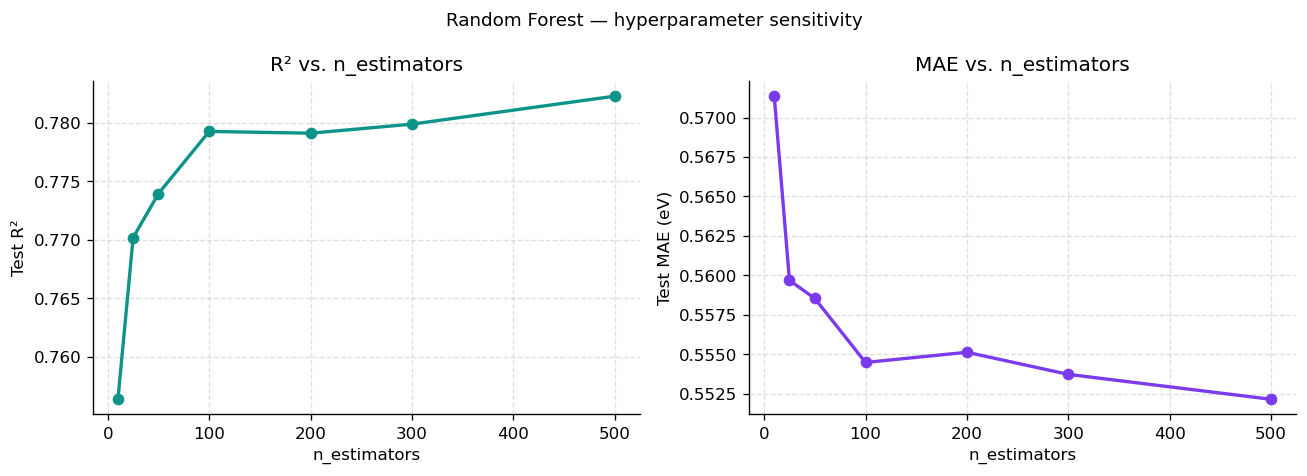

In [18]:
# Demo 1 — RF performance vs. n_estimators
# LECTURE DEMO

import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error

n_estimators_range = [10, 25, 50, 100, 200, 300, 500]
r2_scores, mae_scores = [], []

for n in n_estimators_range:
    rf_n = RandomForestRegressor(n_estimators=n, n_jobs=-1, random_state=42)
    rf_n.fit(X_train, y_train)
    y_pred_n = rf_n.predict(X_test)
    r2_scores.append(r2_score(y_test, y_pred_n))
    mae_scores.append(mean_absolute_error(y_test, y_pred_n))
    print(f"n_estimators={n:4d}  R²={r2_scores[-1]:.3f}  MAE={mae_scores[-1]:.3f} eV")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(n_estimators_range, r2_scores, 'o-', color='#0D9488', lw=2)
axes[0].set_xlabel('n_estimators'); axes[0].set_ylabel('Test R²')
axes[0].set_title('R² vs. n_estimators')
axes[1].plot(n_estimators_range, mae_scores, 'o-', color='#7C3AED', lw=2)
axes[1].set_xlabel('n_estimators'); axes[1].set_ylabel('Test MAE (eV)')
axes[1].set_title('MAE vs. n_estimators')
plt.suptitle('Random Forest — hyperparameter sensitivity', fontsize=11)
plt.tight_layout()
plt.savefig('Day2_n_estimators.png', dpi=150, bbox_inches='tight')
plt.show()

### Demo 2 - Learning curve: are we data-limited?
**Instructor-led demo**

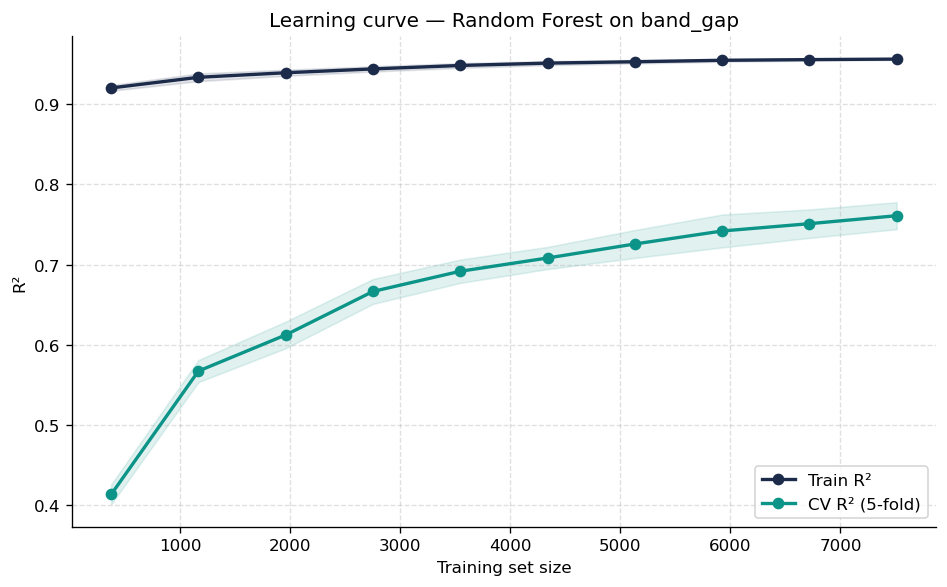

Train-CV gap at full training size: 0.195
Is CV R² still rising at the rightmost point? True


In [19]:
# Demo 2 — Learning curve for the RF model
# LECTURE DEMO

from sklearn.model_selection import learning_curve

train_sizes, train_scores, val_scores = learning_curve(
    RandomForestRegressor(n_estimators=100, n_jobs=-1, random_state=42),
    X, y,
    train_sizes=np.linspace(0.05, 1.0, 10),
    cv=5, scoring='r2', n_jobs=-1
)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(train_sizes, train_scores.mean(1), 'o-', color='#1C2B4A',
        lw=2, label='Train R²')
ax.fill_between(train_sizes,
                train_scores.mean(1) - train_scores.std(1),
                train_scores.mean(1) + train_scores.std(1),
                alpha=0.12, color='#1C2B4A')
ax.plot(train_sizes, val_scores.mean(1), 'o-', color='#0D9488',
        lw=2, label='CV R² (5-fold)')
ax.fill_between(train_sizes,
                val_scores.mean(1) - val_scores.std(1),
                val_scores.mean(1) + val_scores.std(1),
                alpha=0.12, color='#0D9488')
ax.set_xlabel('Training set size'); ax.set_ylabel('R²')
ax.set_title('Learning curve — Random Forest on band_gap')
ax.legend()
plt.tight_layout()
plt.savefig('Day2_learning_curve.png', dpi=150, bbox_inches='tight')
plt.show()

gap = train_scores.mean(1)[-1] - val_scores.mean(1)[-1]
print(f"Train-CV gap at full training size: {gap:.3f}")
print("Is CV R² still rising at the rightmost point?",
      val_scores.mean(1)[-1] > val_scores.mean(1)[-2])

### Demo 3 - Where does the RF fail? Large-error material analysis
**Instructor-led demo**

In [21]:
#Demo 3 — Identify and investigate large-error materials
# LECTURE DEMO

# Use the RF trained in Part C (rf) and its predictions (y_pred_rf)
residuals  = np.abs(y_pred_rf - y_test.values)
formulas   = df['formula'].values if 'formula' in df.columns else ['?']*len(y_test)
crystal_sys = df['crystal_system'].values if 'crystal_system' in df.columns else ['?']*len(y_test)

# Get test-set indices (from the stratified split in B1)
# Reconstruct: y_test indices correspond to the test portion of the original df
idx_sorted = np.argsort(residuals)[::-1]

print("Top 10 largest prediction errors:")
print(f"{'Formula':20s}  {'Crystal sys':15s}  {'Actual':>8}  {'Pred':>8}  {'|Error|':>8}")
print("-"*67)
for pos in idx_sorted[:10]:
    original_idx = y_test.index[pos]
    f = df.loc[original_idx, 'formula'] if 'formula' in df.columns else '?'
    cs = df.loc[original_idx, 'crystal_system'] if 'crystal_system' in df.columns else '?'
    print(
        f"{f:20s}  {cs:15s}  "
        f"{y_test.iloc[pos]:8.3f}  "
        f"{y_pred_rf[pos]:8.3f}  "
        f"{residuals[pos]:8.3f} eV"
    )

print("\nDiscussion: what do the large-error materials have in common?")
print("  → Many are polymorphs (same formula, different structure)")
print("  → Composition-only features cannot distinguish TiO2 rutile from anatase")
print("  → This is the structural information gap Week 11 GNNs address")

Top 10 largest prediction errors:
Formula               Crystal sys        Actual      Pred   |Error|
-------------------------------------------------------------------
Ca(BO2)3              ?                   0.553     5.757     5.204 eV
NaSO4                 ?                   0.000     4.888     4.888 eV
Ba2ZrInO6             ?                   0.000     3.172     3.172 eV
Eu(ClO4)3             ?                   0.000     3.084     3.084 eV
Ba2YbTaO6             ?                   0.000     3.036     3.036 eV
NaEuGeO4              ?                   0.000     2.932     2.932 eV
Li2VGeO5              ?                   0.000     2.880     2.880 eV
CaGd2O4               ?                   3.260     0.416     2.844 eV
Na5WO5                ?                   0.000     2.838     2.838 eV
Ta3Al4O14             ?                   0.000     2.791     2.791 eV

Discussion: what do the large-error materials have in common?
  → Many are polymorphs (same formula, different structur

**Day 2 Discussion questions:**

1. From Demo 1: at what n_estimators does performance plateau? What does this tell you about diminishing returns in ensemble size?

2. From Demo 2: is the CV R² still rising at the largest training size? If yes, would more data help more than better features? If no, what should you try next?

3. From Demo 3: do the large-error materials share a common structural feature that MAGPIE cannot encode? Connect to Week 11 (GNNs, what would a crystal-graph-based model do differently?

*Your answer here:*

1. n_estimators plateau (Demo 1)
From my results, performance plateaus around n_estimators = 100 to 200, where R² goes from 0.779 at 100 to 0.779 at 200 with almost no improvement, and MAE similarly flattens from 0.554 to 0.555 eV. Beyond 100 trees the gains are essentially zero while compute time keeps increasing linearly, which tells us the ensemble has sampled enough feature and sample subsets to stabilize its variance reduction and the remaining error is irreducible bias that more trees cannot fix.

2. Learning curve (Demo 2)
Yes, the CV R² is still slowly rising at the largest training size, going from around 0.40 at 5% data to approximately 0.76 at 100%, and the curve has not fully plateaued. This means the model is still data-limited and adding more experimental oxide entries would likely push CV R² higher before we hit diminishing returns. More data would help more than better features at this stage, though the large gap between Train R² (~0.95) and CV R² (~0.76) also signals that better features or regularization could reduce overfitting independently.

3. Large-error materials and GNNs (Demo 3)
The large-error materials like Ca(BO2)3, NaSO4, Ba2ZrInO6, and Eu(ClO4)3 share the common structural feature of being complex multi-element oxides and polymorphs where composition-only MAGPIE features cannot distinguish between different structural arrangements of the same formula — for example rutile vs anatase TiO2 have identical compositions but very different bandgaps. A crystal-graph-based GNN from Week 11 would encode each atom as a node and each bond as an edge with distance and angle information, allowing it to learn directly from local coordination environments and capture the structural differences that drive the large prediction errors MAGPIE-based models systematically make.

---
**Submission checklist:**
- [ ] All cells executed without errors
- [ ] C4: comparison table complete and scatter plot saved
- [ ] D1: feature importance bar chart saved
- [ ] D2: residual plots saved
- [ ] D3, E3: task cells contain working code
- [ ] All reflection cells answered (no placeholder text)
- [ ] AI disclosure note updated or deleted at the top of the notebook
- [ ] File renamed: `[LastName]_week5.ipynb`
**Final check:** Run `Kernel → Restart & Run All`. All cells must execute without errors before submitting.